In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv("../data/Raw/Titanic-Dataset.csv")

Exploratory Data Analysis (EDA)

In [3]:
df.shape

(891, 12)

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Explore Missing Values

In [6]:
missing_count = df.isnull().sum() #finding missing count

In [7]:
missing_percentage = (missing_count)/len(df) *100  #missing count percentage

In [8]:
#table for missing count & missing%
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percentage.round(2)
})

missing_summary

,Missing Count,Missing %
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [9]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

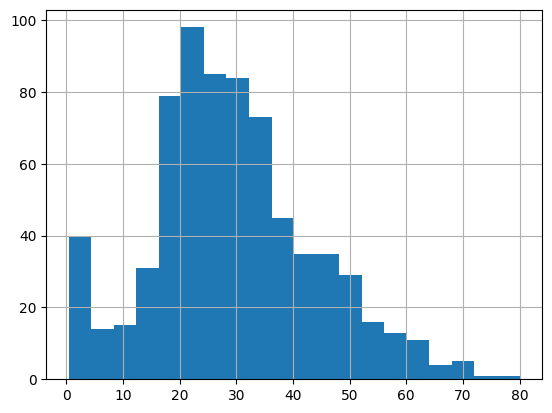

In [10]:
df['Age'].hist(bins=20) #Age is continuous but skewed. Median preserves the central tendency without distortion. It’s a common best practice in production pipelines when imputing skewed numeric data.

In [11]:
df['Cabin'].describe() 

count     204
unique    147
top        G6
freq        4
Name: Cabin, dtype: object

### Missing Values Summary

| Column   | Missing Count | Missing % | Action Taken                  |
|----------|---------------|-----------|-------------------------------|
| Age      | 177           | 19.9%     | Fill with median              |
| Cabin    | 687           | 77.1%     | Drop column / add availability flag |
| Embarked | 2             | 0.2%      | Fill with mode (most frequent) |


Filling Age Column Values

In [12]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_12816\1933487976.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [13]:
df['Age'].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: Age, Length: 891, dtype: bool

In [14]:
#sometimes, the datatype may contain NaN values hence we need to force numeric then find median, then fill it. 
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
age_median = df['Age'].median()
print(age_median)


28.0


In [15]:
df['Age'] = df['Age'].fillna(age_median)

In [16]:
df['Age'].isnull().sum()

np.int64(0)

Dropping Cabin Column Completely

In [17]:
df.drop('Cabin', axis=1, inplace=True)

Filling Embarked Missing Values

In [18]:
df['Embarked'].isnull().sum()

np.int64(2)

In [19]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [20]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_12816\3744086084.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [21]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


C:\Users\ACER\AppData\Local\Temp\ipykernel_12816\411043493.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [22]:
df['Embarked'].unique()


<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [23]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [24]:
mode_value = df['Embarked'].mode()[0]   # should be 'S'
df['Embarked'] = df['Embarked'].fillna(mode_value)


In [25]:
df['Embarked'].isnull().sum()


np.int64(0)

In [26]:
df.info() 
# Pclass: Ticket class: 1 = First, 2 = Second, 3 = Third.
# SibSp: Number of siblings/spouses aboard. Can be combined into FamilySize.
# Parch: Number of parents/children aboard. Also part of FamilySize.
# Embarked: Port of embarkation (where the passenger boarded):
# C = Cherbourg (France)
# Q = Queenstown (Ireland)
# S = Southampton (England)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


Exploring Data Types

In [27]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object

In [28]:
df['Age'].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

Group Columns by Intended Type

In [29]:
id_cols = ['PassengerId', 'Survived']
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch' ]
categorical_cols = ['Sex', 'Embarked', 'Pclass']
text_cols = ['Name', 'Ticket', 'Cabin']

In [30]:
df[id_cols].dtypes

PassengerId    int64
Survived       int64
dtype: object

In [31]:
df[text_cols].dtypes

KeyError: "['Cabin'] not in index"

In [ ]:
df[numeric_cols].dtypes

Age      float64
Fare     float64
SibSp      int64
Parch      int64
dtype: object

In [ ]:
df[categorical_cols].dtypes

Sex           str
Embarked      str
Pclass      int64
dtype: object

### Data Type Summary

| Column      | Current Type | Intended Type | Notes |
|-------------|--------------|---------------|-------|
| PassengerId | int64        | ID (ignore)   | Unique identifier |
| Survived    | int64        | Target        | 0 = No, 1 = Yes |
| Pclass      | int64        | Category      | Socio-economic class |
| Name        | object       | Text          | Use for Title feature |
| Sex         | object       | Category      | Male/Female |
| Age         | float64      | Numeric       | Missing values present |
| SibSp       | int64        | Numeric       | Family size component |
| Parch       | int64        | Numeric       | Family size component |
| Ticket      | object       | Text          | Grouping passengers |
| Fare        | float64      | Numeric       | Continuous variable |
| Cabin       | object       | Text          | Mostly missing |
| Embarked    | object       | Category      | C, Q, S |


Univariate Analysis

4.1 Numeric Columns

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

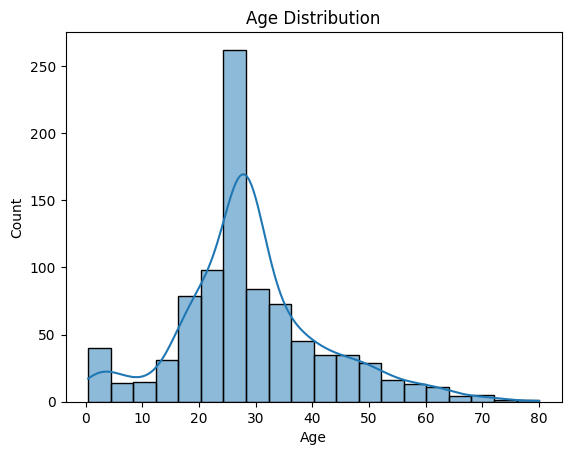

In [37]:
sns.histplot(df['Age'], bins = 20, kde = True)
plt.title("Age Distribution")
plt.show()

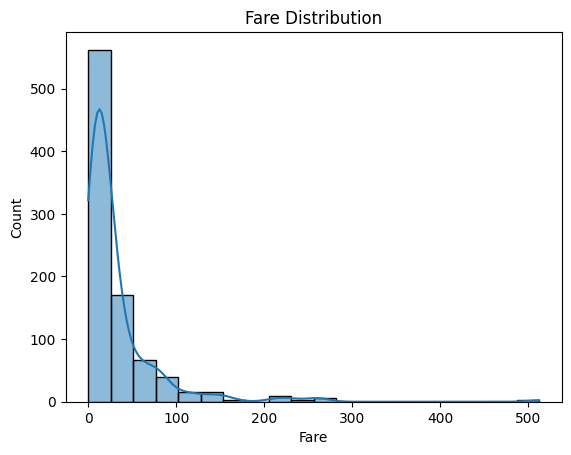

In [38]:
sns.histplot(df['Fare'], bins = 20, kde=True)
plt.title("Fare Distribution")
plt.show()

4.2 Categorical Columns

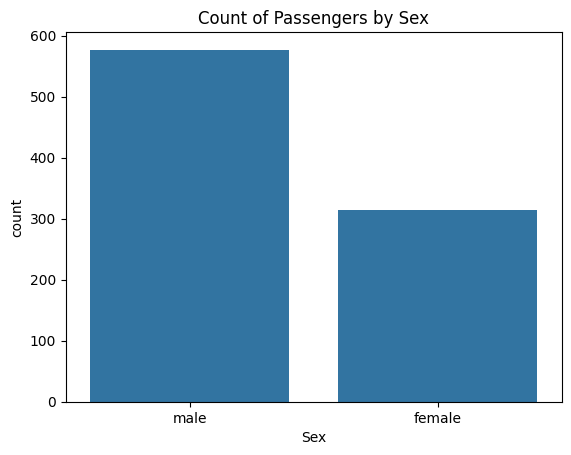

In [39]:
sns.countplot(x='Sex', data=df)
plt.title('Count of Passengers by Sex')
plt.show()

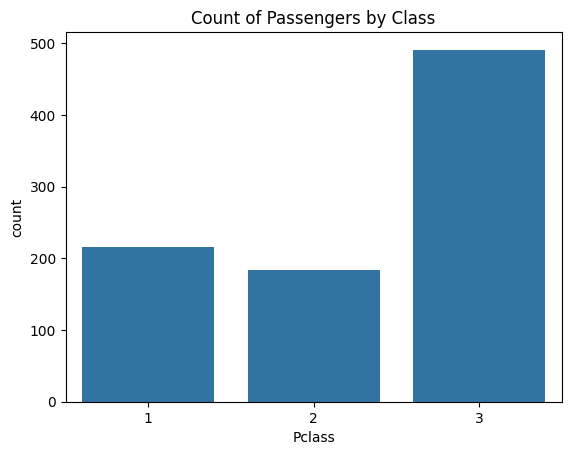

In [40]:
sns.countplot(x='Pclass', data=df)
plt.title('Count of Passengers by Class')
plt.show()

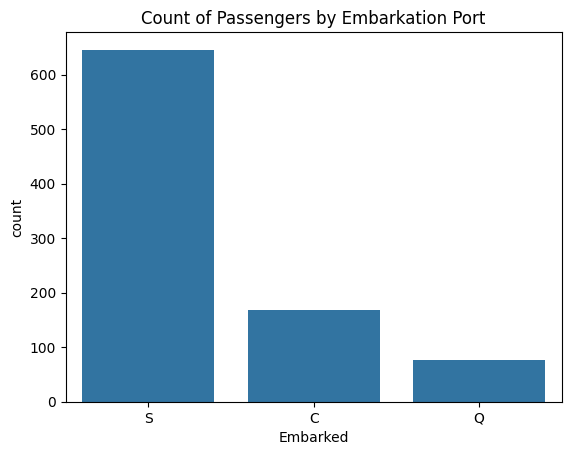

In [41]:
sns.countplot(x='Embarked', data=df)
plt.title('Count of Passengers by Embarkation Port')
plt.show()

4.3 Survival by Category

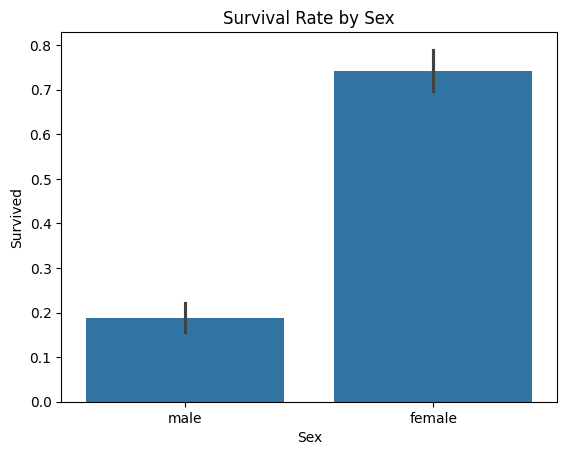

In [42]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

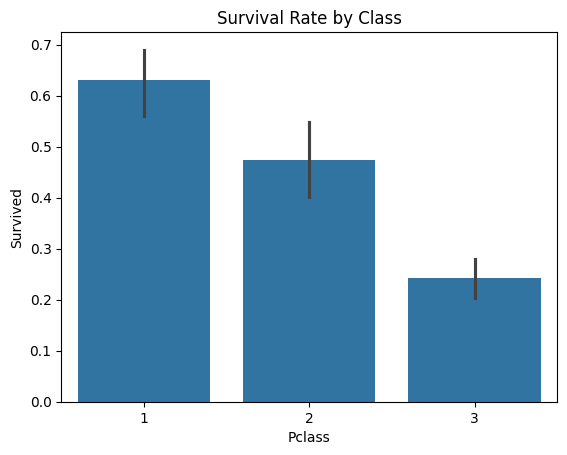

In [43]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

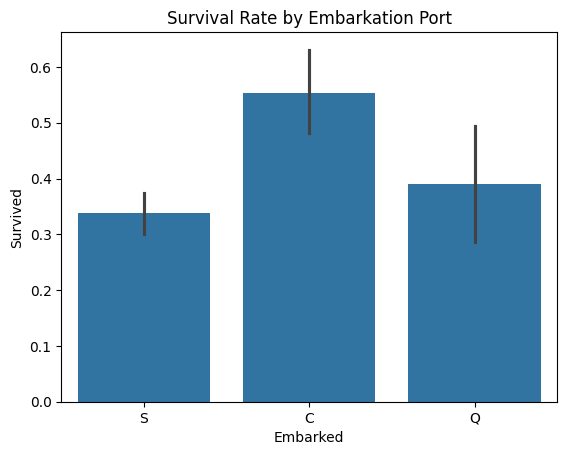

In [44]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarkation Port')
plt.show()

### Step 4 Findings: Univariate Exploration
- Age: Most passengers between 20–40 years.
- Fare: Skewed distribution, some very high fares.
- Sex: More males than females, but females had higher survival.
- Pclass: Majority in 3rd class, survival higher in 1st class.
- Embarked: Most from Southampton, survival varied by port.

Step 5: Bivariate Exploration

5.1 Age VS Survival

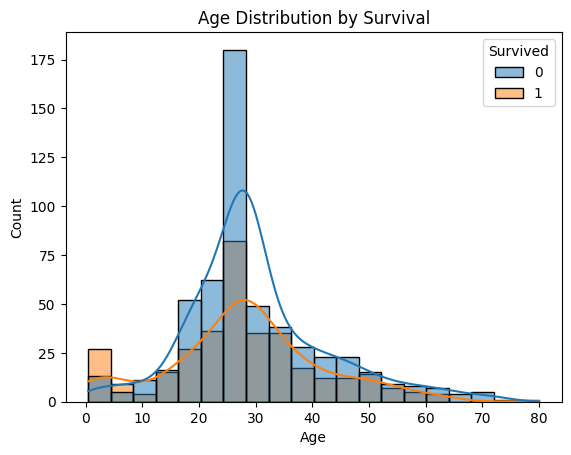

In [45]:
sns.histplot(data=df, x='Age', hue='Survived', bins=20, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

5.2 Fare vs Survival

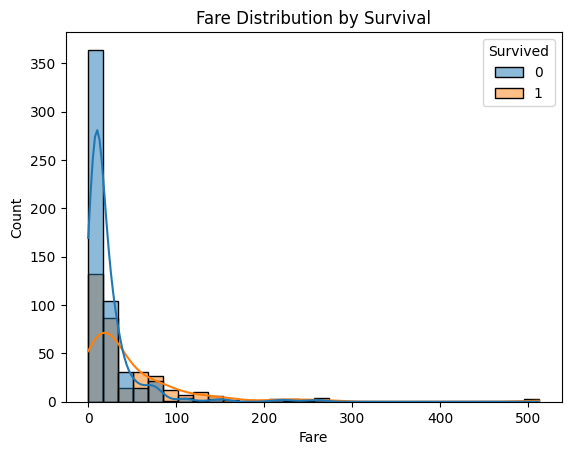

In [46]:
sns.histplot(data=df, x='Fare', hue='Survived', bins=30, kde=True)
plt.title('Fare Distribution by Survival')
plt.show()

5.3 Pclass vs Fare

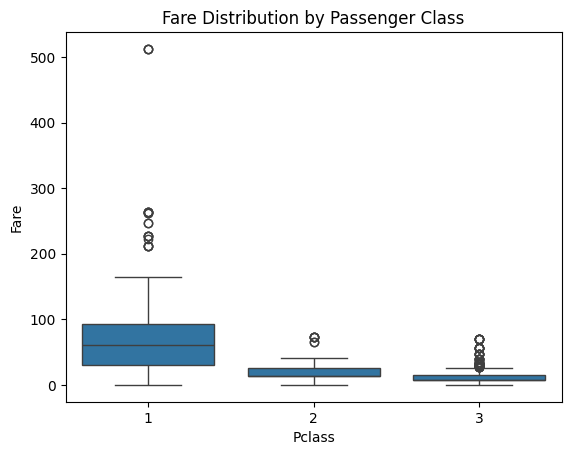

In [ ]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution by Passenger Class')
plt.show()

5.4 Sex vs Survival

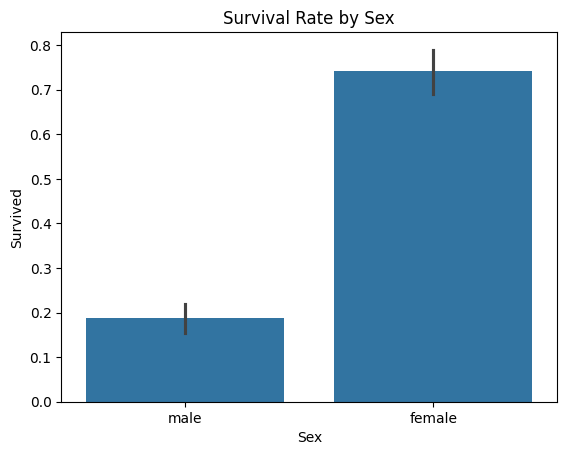

In [48]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()


5.5 Embarked VS Survival

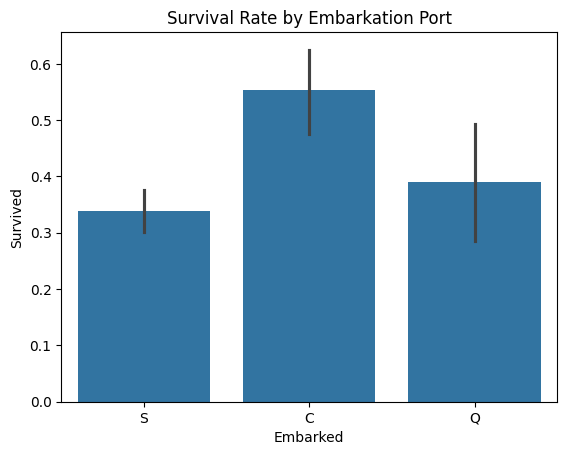

In [49]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarkation Port')
plt.show()


5.6 Family Size vs Survival

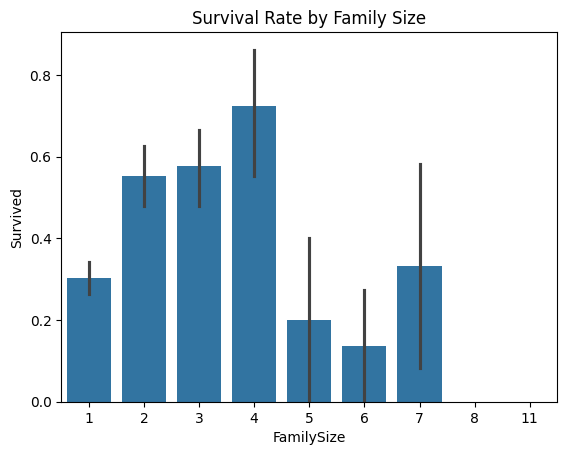

In [50]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 #family size feature

sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

### Step 5 Findings: Bivariate Exploration
- Age vs Survival: Younger passengers had slightly higher survival.
- Fare vs Survival: Higher fares correlated with higher survival.
- Pclass vs Fare: Clear separation of fare ranges by class.
- Sex vs Survival: Females had much higher survival rates.
- Embarked vs Survival: Survival varied by port of embarkation.
- Family Size vs Survival: Small families survived more often than large ones.
